# Supress Warning and Import Libraries

In [17]:
def warn(*args, **kwargs):
  pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Data

In [19]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%203/data/CustomerData.csv'
data = pd.read_csv(url)
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Access Data Details

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [21]:
data.CustomerID.is_unique

True

In [22]:
data.drop('CustomerID', axis = 1, inplace = True)
data.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


 # Encode Column Gender


In [23]:
data["Gender"] = data["Gender"].map({"Male": 1, "Female": 0})
data

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


# Calculate and Plot Skewness

Skewness =  0.48556885096681657


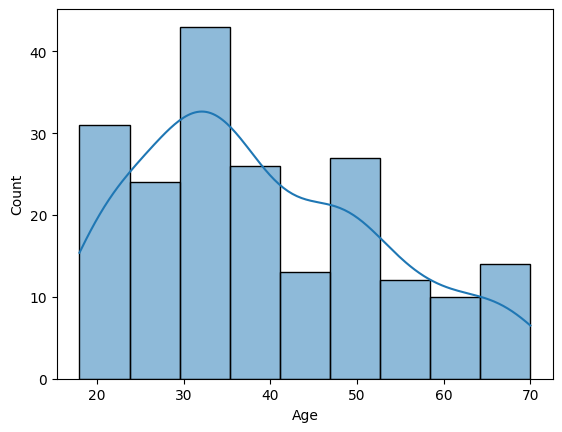

In [24]:
print('Skewness = ', data['Age'].skew())
sns.histplot(data['Age'], kde = True)
plt.show()

Skewness =  0.3218425498619055


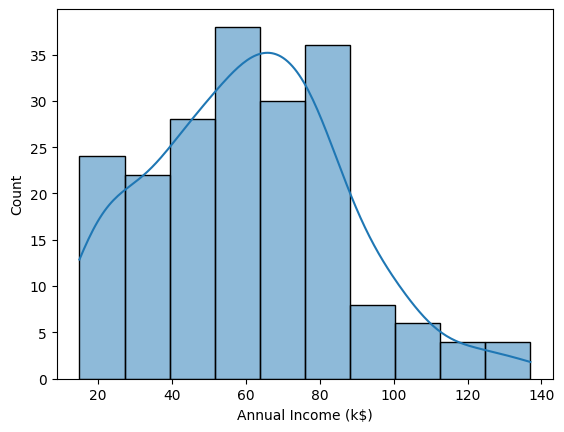

In [25]:
print('Skewness = ', data['Annual Income (k$)'].skew())
sns.histplot(data['Annual Income (k$)'], kde = True)
plt.show()

Skewness =  -0.047220201374263374


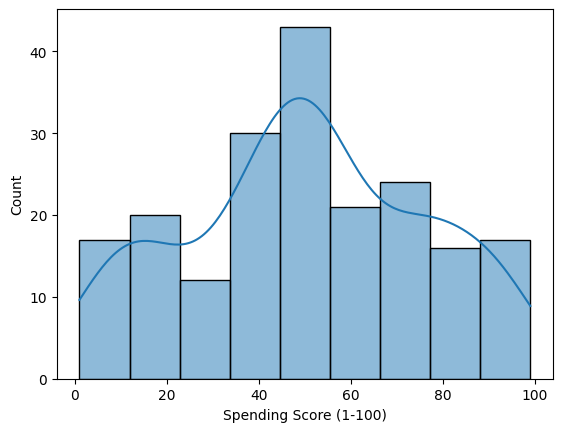

In [26]:
print('Skewness = ', data['Spending Score (1-100)'].skew())
sns.histplot(data['Spending Score (1-100)'], kde = True)
plt.show()

#Draw Heatmap

<Axes: >

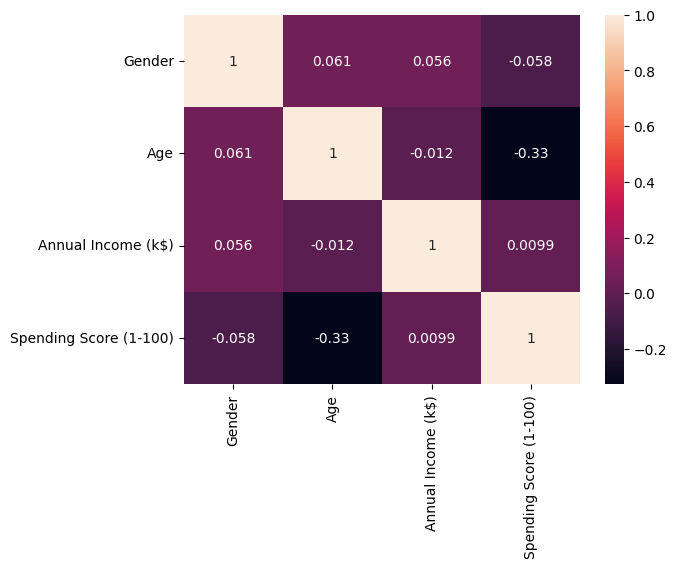

In [27]:
corr_data = data.corr()
sns.heatmap(corr_data, annot = True)

# Correlation between features


In [28]:
for x in range(len(data.columns)):
  corr_data.iloc[x,x] = 0
corr_data.idxmax()

,0
Gender,Age
Age,Gender
Annual Income (k$),Gender
Spending Score (1-100),Annual Income (k$)


# K-Means Clustering

In [29]:
from sklearn.cluster import KMeans

inertia_values = []
for n_clusters in range(1, 11):
  kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
  kmeans.fit(data)
  inertia_values.append(kmeans.inertia_)

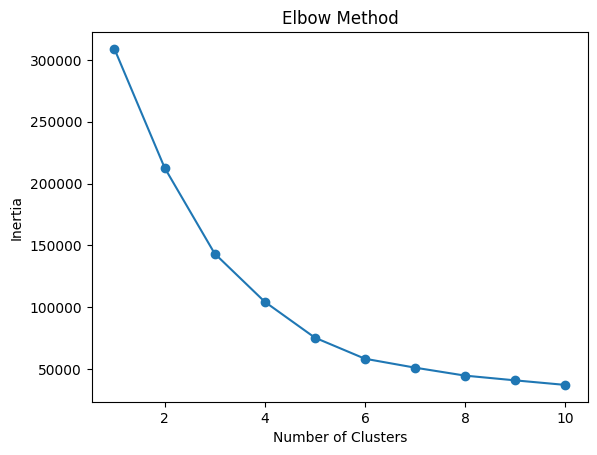

In [30]:
plt.plot(range(1, 11), inertia_values, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

#Agglomerative Clustering


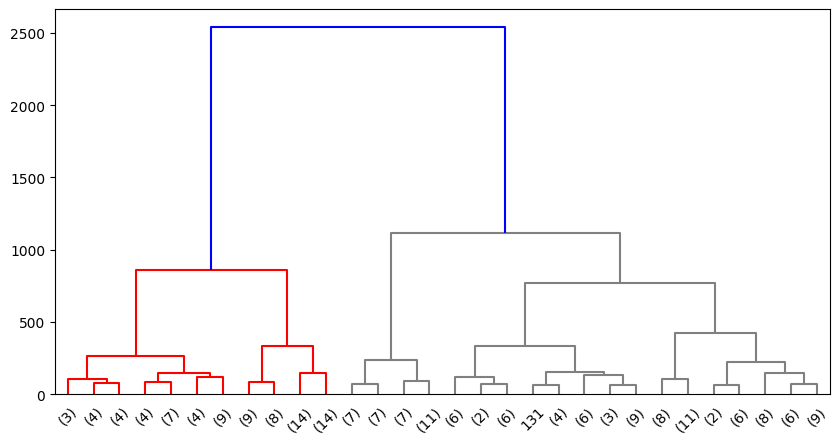

In [31]:
from scipy.cluster import hierarchy
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

ag = AgglomerativeClustering(n_clusters = 10, linkage = 'ward', compute_full_tree = True)
ag.fit(data)

Z = hierarchy.linkage(ag.children_, method = 'ward')
fig, ax = plt.subplots(figsize = (10,5))
hierarchy.set_link_color_palette(['red','gray'])
den = hierarchy.dendrogram (Z, orientation = 'top',
                            p = 30, truncate_mode = 'lastp',
                            show_leaf_counts = True, ax = ax,
                            above_threshold_color = 'blue')
plt.show()

# DBSCAN

In [32]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps = 0.5, min_samples = 20)
db = db.fit(data)
clusters = db.labels_
pd.DataFrame(clusters).nunique()

,0
0,1
